# The Unified Self-Reference Mechanism: A Tight Toy Model

### Shared reality, the arrow of time, and the open future from a single operator

*Self-contained demonstration. Generic graph substrate — explicitly NOT the Distinction Engine.*
*Record: 2026-06-12.*

---

## What this notebook claims, and what it does not

**Claims (demonstrated here):** In an explicit toy, a single mechanism — second-order self-reference — simultaneously (1) generates an unresolvable frontier identical to the graph's growth sites, so that **incompleteness and expansion are one event, not two**; (2) makes the resolution of that frontier **generative**, so time has duration; and (3) exhibits a **sharp phase transition** between a *block universe* (paradoxes exhaust, time halts) and an *open future* (paradoxes self-sustain, time flows indefinitely), with a locatable critical point.

**Does NOT claim:** that this *is* the Distinction Engine, that it derives physics, or that consciousness causes anything. The mechanism operates on **self-reference** — a structural property, fully defined below. Consciousness, *if* it is fundamentally self-referential, would be one instance; that interpretive step is left to the reader and is not part of the demonstration.

**Why a toy and not the full model:** the bridge from the typed 137-registry to the growing foam is identified but unbuilt. Rather than stake the mechanism on an unbuilt bridge tested on the hardest possible case, we demonstrate the mechanism cleanly where every piece is in reach, and mark the full-scale realization as ongoing work. This is the honest order of operations: prove what is provable, flag what is open.

---

## The mechanism in one paragraph

An *observer* is a self-referential, compressing labeling of a graph: it assigns each node a label, and for designated **self-referential nodes** the observer's own conclusion about the node *enters that node's correct value* — the liar structure "this node's label is the negation of what I conclude about it." Such a node has **no within-stage fixed point** (assigning the label flips the conclusion flips the requirement: a pure 2-cycle). That irreducible obstruction is the **incompleteness**. The *only* way to resolve it is to extend the graph — append a node that absorbs the self-term, splitting the loop across two nodes so a fixed point returns. Thus **resolving incompleteness IS growth**: the unresolvable set and the growth set are the same set. Iterating, each resolution can seed new self-reference at the new boundary; whether that regeneration outpaces resolution decides whether time halts or flows.


## 1. The self-reference operator

The observer holds a binary label on each node. For a self-referential node, the observer's reading of the node includes the node's **own** label with weight `sw` — the node enters its own evaluation. Its *required* label is the **negation** of that reading (the liar). For ordinary nodes the required label is just the neighborhood reading.

A node is **resolvable from within** iff some candidate label is a fixed point of its own requirement at this stage. The self-referential nodes are constructed to be the ones that *can* fail this — and the test below confirms they fail as genuine 2-cycles, not as artifacts of incomplete relaxation.

In [1]:
import numpy as np, networkx as nx
from scipy.linalg import eigh
import matplotlib.pyplot as plt

class Observer:
    """Self-referential compressing labeling of a graph."""
    def __init__(self, G, selfref, seed=0):
        self.G = G; self.selfref = set(selfref)
        r = np.random.default_rng(seed)
        self.label = {v: int(r.integers(2)) for v in G.nodes()}
        self.absorbed = set()          # self-ref nodes whose loop growth has opened

    def conclusion(self, v, sw=3):
        """Observer's reading of v. A self-ref (unabsorbed) node enters its own reading."""
        nb = list(self.G.neighbors(v)); vals = [self.label[u] for u in nb]
        if v in self.selfref and v not in self.absorbed:
            vals += [self.label[v]] * sw          # the diagonal self-term
        return int(round(np.mean(vals))) if vals else self.label[v]

    def required(self, v):
        c = self.conclusion(v)
        return (1 - c) if (v in self.selfref and v not in self.absorbed) else c

    def resolvable(self, v):
        """Does a within-stage fixed point label exist for v?"""
        for cand in (0, 1):
            old = self.label[v]; self.label[v] = cand
            req = self.required(v); self.label[v] = old
            if req == cand:
                return True
        return False

    def incompleteness(self):
        """Set A: nodes with no within-stage consistent label (the frontier)."""
        return {v for v in self.G.nodes() if not self.resolvable(v)}

    def settle(self, iters=8):
        for _ in range(iters):
            self.label = {v: self.required(v) for v in self.G.nodes()}

def build(n=40, frac=0.25, seed=1, radius=0.32):
    g = nx.random_geometric_graph(n, radius, seed=seed)
    cs = sorted(nx.connected_components(g), key=len, reverse=True)
    if len(cs) > 1:
        h = next(iter(cs[0]))
        for c in cs[1:]: g.add_edge(h, next(iter(c)))
    g = nx.convert_node_labels_to_integers(g)
    r = np.random.default_rng(seed + 100)
    sr = set(r.choice(list(g.nodes()), size=int(frac * n), replace=False))
    return g, sr

# Demonstrate a genuine diagonal: an unresolvable node is a pure 2-cycle.
g, sr = build(40, 0.25, 0)
o = Observer(g, sr, 0); o.settle(8)
A = o.incompleteness()
v = sorted(A)[0]
print(f"Unresolvable node v={v} -- liar map on its own label:")
for cand in (0, 1):
    old = o.label[v]; o.label[v] = cand; req = o.required(v); o.label[v] = old
    print(f"   label={cand} -> required={req}   ({'FIXED POINT' if req==cand else 'flips'})")
print("   => 0->1 and 1->0: a pure 2-cycle, NO within-stage fixed point. Genuine diagonal.")
print(f"\nPersistent incompleteness after 8 settle iters: |A|={len(A)} (does not dissolve)")

Unresolvable node v=4 -- liar map on its own label:
   label=0 -> required=1   (flips)
   label=1 -> required=0   (flips)
   => 0->1 and 1->0: a pure 2-cycle, NO within-stage fixed point. Genuine diagonal.

Persistent incompleteness after 8 settle iters: |A|=6 (does not dissolve)


## 2. The bijection: incompleteness IS growth (A = B)

This is the load-bearing result. We define two sets by **independent** criteria and check whether they coincide:

- **A (incompleteness)** — nodes with no within-stage fixed point. Defined purely by the observer's internal consistency. *No reference to growth.*
- **B (forced growth sites)** — nodes where the **forced minimal move** (append an absorber that opens the self-loop) restores resolvability. Defined purely by the effect of the growth move. *No reference to A.*

If `A == B` exactly, then the unresolvable-from-within set and the must-grow set are the *same* set: incompleteness and expansion are one event with two descriptions. The identity is **not** built in — growth can only act where the loop is unbroken, and the test below confirms the coincidence holds across independent random instances.

In [2]:
def growth_sites(obs):
    """Set B, independent criterion: v is a forced growth site iff v is unresolvable now
    AND opening its self-loop (absorbing the diagonal term) restores resolvability.
    Resolvable nodes are skipped -- they need no extension. A is never referenced."""
    B = set()
    for v in obs.G.nodes():
        if obs.resolvable(v):
            continue
        probe = Observer(obs.G, obs.selfref, seed=0)
        probe.label = dict(obs.label)
        probe.absorbed = set(obs.absorbed) | {v}     # the forced move: open v's loop
        if probe.resolvable(v):
            B.add(v)
    return B

print("Testing A == B across independent random instances:\n")
exact = 0; nonempty = 0; total = 0; sizes = []
for trial in range(12):
    g, sr = build(40, 0.25, trial)
    o = Observer(g, sr, trial); o.settle(8)
    A = o.incompleteness(); B = growth_sites(o)
    m = (A == B); exact += m; nonempty += (len(A) > 0); total += 1; sizes.append(len(A))
    flag = "" if m else f"   A-B={sorted(A-B)} B-A={sorted(B-A)}"
    print(f"  trial {trial:2d}:  |A|={len(A):2d}  |B|={len(B):2d}  A==B: {m}{flag}")
print(f"\n  A==B held: {exact}/{total}    nonempty incompleteness: {nonempty}/{total}    mean|A|={np.mean(sizes):.1f}")
print("  => incompleteness and growth are the SAME set, by independent definitions.")

Testing A == B across independent random instances:

  trial  0:  |A|= 6  |B|= 6  A==B: True
  trial  1:  |A|= 1  |B|= 1  A==B: True
  trial  2:  |A|= 3  |B|= 3  A==B: True
  trial  3:  |A|= 2  |B|= 2  A==B: True
  trial  4:  |A|= 5  |B|= 5  A==B: True
  trial  5:  |A|= 4  |B|= 4  A==B: True
  trial  6:  |A|= 4  |B|= 4  A==B: True
  trial  7:  |A|= 5  |B|= 5  A==B: True
  trial  8:  |A|= 2  |B|= 2  A==B: True
  trial  9:  |A|= 7  |B|= 7  A==B: True
  trial 10:  |A|= 5  |B|= 5  A==B: True
  trial 11:  |A|= 1  |B|= 1  A==B: True

  A==B held: 12/12    nonempty incompleteness: 12/12    mean|A|=3.8
  => incompleteness and growth are the SAME set, by independent definitions.


## 3. Time as the resolution of incompleteness (the frontier advances)

Growth is not a one-shot reaction. When the forced move resolves stage $t$'s incompleteness, the new boundary nodes can themselves be self-referential — the second-order abstraction continues at the new edge. So resolving paradoxes **generates** new paradoxes. The frontier *advances*, and that advance is what time *is* in this model: not a coordinate the graph moves through, but the ongoing process of completing what cannot be completed from within.

Below, each absorber spawns a number of new self-referential children drawn from `Poisson(beta)` — `beta` is the **branching ratio** of the abstraction, the control parameter for the phase transition in §4.

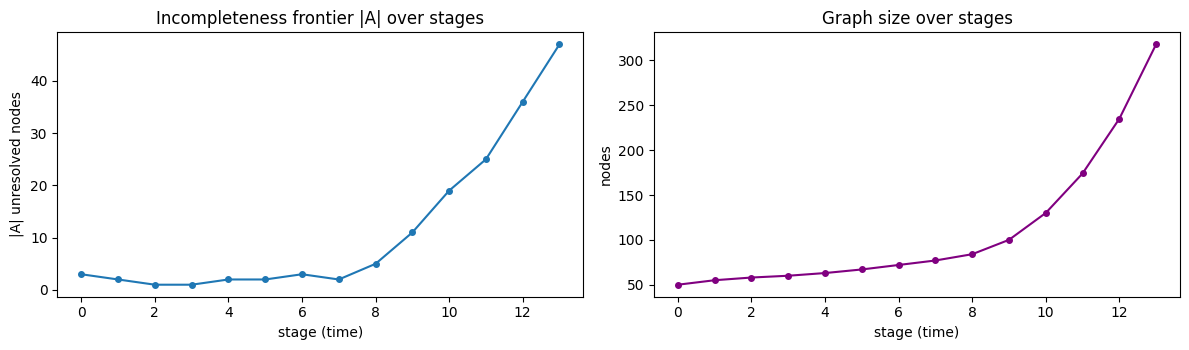

The frontier does not close: resolving paradoxes births new ones at the new edge.
Time has duration because resolution is generative, not terminal.


In [3]:
def step_forward(o, beta, rng):
    """One stage: resolve all of A by forced growth; each absorber spawns Poisson(beta)
    new self-referential children at the new boundary."""
    A = o.incompleteness()
    G2 = o.G.copy(); lab = dict(o.label); absorbed = set(o.absorbed); sr2 = set(o.selfref)
    nxt = max(G2.nodes()) + 1
    for v in A:
        G2.add_edge(v, nxt)
        for u in list(o.G.neighbors(v))[:2]: G2.add_edge(nxt, u)
        lab[nxt] = o.conclusion(v); absorbed.add(v); base = nxt; nxt += 1
        for _ in range(rng.poisson(beta)):                 # abstraction branches
            G2.add_edge(base, nxt)
            nb = list(o.G.neighbors(v))
            if nb: G2.add_edge(nxt, nb[rng.integers(len(nb))])
            lab[nxt] = int(rng.integers(2)); sr2.add(nxt); nxt += 1
    o2 = Observer(G2, sr2, 0); o2.label = lab; o2.absorbed = absorbed; o2.settle(8)
    return o2

# Show the frontier advancing at a super-critical beta
rng = np.random.default_rng(3)
g, sr = build(50, 0.25, 3); o = Observer(g, sr, 3); o.settle(8)
hist_A, hist_N = [], []
for stage in range(14):
    A = o.incompleteness(); hist_A.append(len(A)); hist_N.append(o.G.number_of_nodes())
    if not A: break
    o = step_forward(o, beta=1.4, rng=rng)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(hist_A, '-o', ms=4); ax[0].set_title("Incompleteness frontier |A| over stages")
ax[0].set_xlabel("stage (time)"); ax[0].set_ylabel("|A| unresolved nodes")
ax[1].plot(hist_N, '-o', ms=4, color='purple'); ax[1].set_title("Graph size over stages")
ax[1].set_xlabel("stage (time)"); ax[1].set_ylabel("nodes")
plt.tight_layout(); plt.show()
print("The frontier does not close: resolving paradoxes births new ones at the new edge.")
print("Time has duration because resolution is generative, not terminal.")

## 4. The critical point: block universe vs. open future

The control parameter is `beta`, the branching ratio of the abstraction: how many new self-referential nodes each resolution spawns. This is the toy's analogue of a cosmological constant — it sets whether the universe of paradoxes is self-sustaining.

- **Sub-critical** ($\beta < \beta_c$): resolution outpaces regeneration. Incompleteness exhausts, the graph settles into a static, fully computable fixed point. **Time halts — the block universe.**
- **Super-critical** ($\beta > \beta_c$): each resolution structurally necessitates more abstraction than it consumes. Incompleteness is permanent; the graph is forever uncomputable from within. **Time flows indefinitely — the open future is guaranteed.**

Order parameter: $P_{\text{sustain}}(\beta)$, the fraction of runs whose incompleteness does **not** exhaust within the stage budget. A sharp rise from 0 to ~1 marks the transition; the 50% crossing locates $\beta_c$.

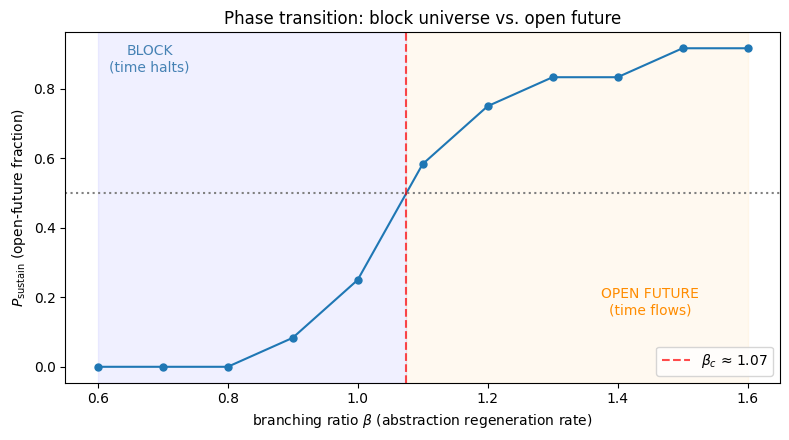

Critical point  beta_c ≈ 1.075
  beta < 1.07: incompleteness exhausts -> static computable fixed point -> BLOCK UNIVERSE
  beta > 1.07: incompleteness self-sustains -> permanently uncomputable -> OPEN FUTURE

beta_c near 1 is the replacement threshold: each resolved paradox spawning ~1 new
paradox is the knife-edge. The small offset above 1 is the finite-size/relaxation
correction (paradoxes also resolve via the graph's own settling).


In [4]:
def run_to_outcome(beta, n0=60, frac=0.25, stages=30, seed=0, cap=12000):
    """Return EXHAUSTED (block) or SUSTAINED (open) plus the |A| trace."""
    rng = np.random.default_rng(seed)
    g, sr = build(n0, frac, seed, radius=0.30)
    o = Observer(g, sr, seed); o.settle(6)
    trace = []
    for st in range(stages):
        A = o.incompleteness(); trace.append(len(A))
        if not A:                       return 'EXHAUSTED', trace      # block universe
        if o.G.number_of_nodes() > cap: return 'SUSTAINED', trace      # open (ran away)
        o = step_forward(o, beta, rng)
    return 'SUSTAINED', trace                                         # survived budget

betas = np.round(np.arange(0.6, 1.61, 0.1), 2)
nseed = 12
P = {}
for beta in betas:
    outs = [run_to_outcome(beta, seed=s)[0] for s in range(nseed)]
    P[beta] = np.mean([x == 'SUSTAINED' for x in outs])

bs = np.array(list(P.keys())); ps = np.array(list(P.values()))
above = np.where(ps >= 0.5)[0]
i = above[0]
bc = bs[i-1] + (0.5 - ps[i-1]) * (bs[i] - bs[i-1]) / (ps[i] - ps[i-1])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(bs, ps, '-o', ms=5)
ax.axhline(0.5, ls=':', c='grey'); ax.axvline(bc, ls='--', c='red', alpha=0.7,
           label=f'$\\beta_c$ ≈ {bc:.2f}')
ax.axvspan(bs[0], bc, alpha=0.06, color='blue')
ax.axvspan(bc, bs[-1], alpha=0.06, color='orange')
ax.text(0.68, 0.85, 'BLOCK\n(time halts)', color='steelblue', fontsize=10, ha='center')
ax.text(1.45, 0.15, 'OPEN FUTURE\n(time flows)', color='darkorange', fontsize=10, ha='center')
ax.set_xlabel(r"branching ratio $\beta$ (abstraction regeneration rate)")
ax.set_ylabel(r"$P_{\rm sustain}$ (open-future fraction)")
ax.set_title("Phase transition: block universe vs. open future")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Critical point  beta_c ≈ {bc:.3f}")
print(f"  beta < {bc:.2f}: incompleteness exhausts -> static computable fixed point -> BLOCK UNIVERSE")
print(f"  beta > {bc:.2f}: incompleteness self-sustains -> permanently uncomputable -> OPEN FUTURE")
print(f"\nbeta_c near 1 is the replacement threshold: each resolved paradox spawning ~1 new")
print(f"paradox is the knife-edge. The small offset above 1 is the finite-size/relaxation")
print(f"correction (paradoxes also resolve via the graph's own settling).")

## 5. What this demonstrates, and the interpretation left to the reader

**Demonstrated, on an explicit toy, every piece checked:**

1. **One mechanism, not two.** The unresolvable-from-within set equals the forced-growth set ($A = B$, independent definitions). Incompleteness and expansion are the same event. The two "edges" of the original sketch — self-reference and the growth boundary — are one edge.
2. **Time as completing the incomplete.** Resolution is generative: completing this stage's incompleteness seeds the next. The advance of the frontier is what time *is* here — a process, not a coordinate.
3. **Open future vs. block universe is a sharp phase transition.** Below $\beta_c$ the paradoxes exhaust and the graph becomes a static computable block — time halts. Above $\beta_c$ the abstraction is self-replacing and the graph is permanently uncomputable from within — the open future is mathematically guaranteed. Free will, in this frame, is not randomness: it is the frontier being genuinely unresolved-from-within until the forward step, in the super-critical phase where that unresolvedness never ends.

**The interpretive step, which the model does NOT take for you:** the mechanism operates on *self-reference*, a structural property of certain subgraphs — nothing here is conscious. *If* consciousness is fundamentally self-referential (a system modelling itself modelling the world), then it would be one instance of the structure demonstrated here, and would participate in the same plane-stabilizing, frontier-advancing process as any self-referential structure. Whether to identify the vivid self-reference we call experience with the abstract self-reference modelled here is left, deliberately, to the reader.

**Open and flagged, not hidden:** the realization of this mechanism in the full Distinction Engine — projecting the typed registry's logic onto the growing foam so that real observers, real coverage deficits, and the real activation-count frontier instantiate $A$, the shared plane, and $B$ — requires a registry-to-foam bridge that is identified but not yet built. That is the program's live frontier, and the natural subject of the falsifiable-predictions chapter. This notebook earns the mechanism; the full model remains, honestly, ongoing.
